In [1]:
import  numpy as np
import pandas as pd

data=pd.read_csv("spam.csv", encoding='latin-1')

1. DATA CLEANING 


In [2]:
## Dropping last 3 Columns as they have 90%+ NUll Values.

data=data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])


In [3]:
# Renaming the columns for better understanding 
# v1 -> target , v2 -> text

data.rename(columns={'v1':'target','v2':'text'},inplace=True)
data.sample(5)

,target,text
2812,ham,Enjoy the showers of possessiveness poured on ...
1579,ham,"Why is that, princess? I bet the brothas are a..."
2083,ham,"you are sweet as well, princess. Please tell m..."
3558,spam,URGENT! We are trying to contact U Todays draw...
4610,ham,Wat time Ì_ finish?


In [4]:
# Convert 'ham'->1 and 'spam' ->0 for processing

data['target']=data['target'].map({'ham':0,'spam':1})

data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
# Chcek for missing values 

data.isna().sum() # No Null Values

#Check for dupliactes values 

data.duplicated().sum()  # 403 duplicated values

# Dropping duplicte values

data.drop_duplicates(keep='first',inplace=True)

data.shape

(5169, 2)

2. Exploratory Data Analysis (EDA)

<Axes: ylabel='count'>

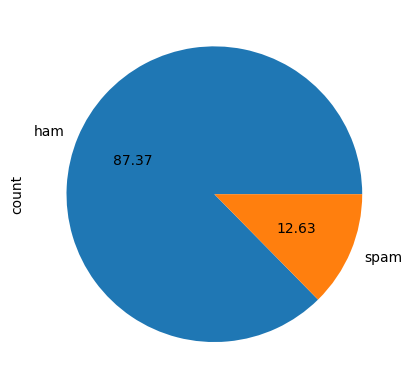

In [6]:
import matplotlib.pyplot as plt

# counting 1 and 0 in target

data['target'].value_counts().plot(kind='pie',labels=['ham','spam'],autopct="%0.2f")

In [7]:
import nltk
nltk.download('punkt_tab')



[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
# Countng characters in text message

data['no_of_characters']=data['text'].apply(len)
data.head()

,target,text,no_of_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [9]:
# counting words in text message

data['no_of_words']=data['text'].apply(lambda x:len( nltk.word_tokenize(x)))
data.sample(7)

,target,text,no_of_characters,no_of_words
5064,0,But your brother transfered only &lt;#&gt; +...,63,23
1543,1,Hello from Orange. For 1 month's free access t...,156,33
991,0,Hi im having the most relaxing time ever! we h...,142,34
5361,0,Yep get with the program. You're slacking.,42,10
4087,0,He needs to stop going to bed and make with th...,63,13
2294,1,You have 1 new message. Please call 08718738034.,48,10
2515,0,Bognor it is! Should be splendid at this time ...,54,13


In [10]:
#counting sentences in text message

data['no_of_sentences']=data['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
data.head()

,target,text,no_of_characters,no_of_words,no_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [11]:
# Analysis for Ham i.e 0

data[data['target']==0][['no_of_characters','no_of_words','no_of_sentences']].describe()


,no_of_characters,no_of_words,no_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [12]:
# Analysis for Spam i.e 1

data[data['target']==1][['no_of_characters','no_of_words','no_of_sentences']].describe()

,no_of_characters,no_of_words,no_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='no_of_characters', ylabel='Count'>

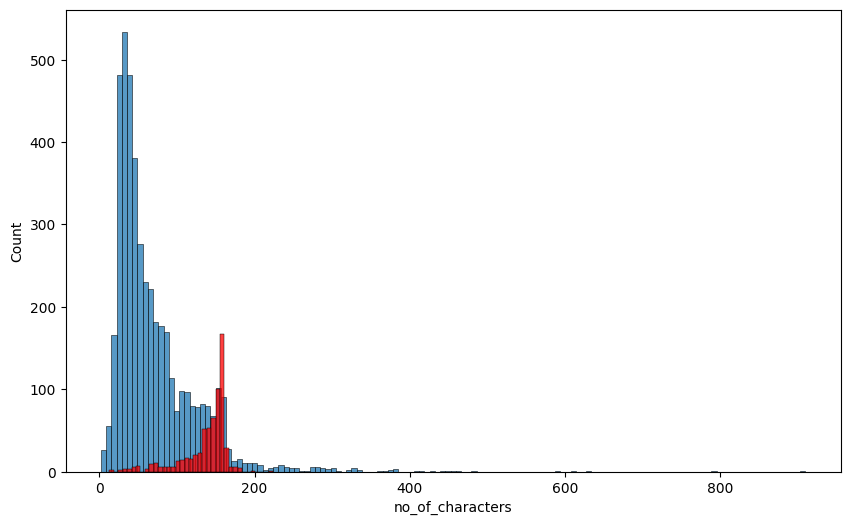

In [13]:
import seaborn as sns 

plt.figure(figsize=(10,6))
sns.histplot(data[data['target']==0]['no_of_characters'])
sns.histplot(data[data['target']==1]['no_of_characters'],color='red')

<Axes: >

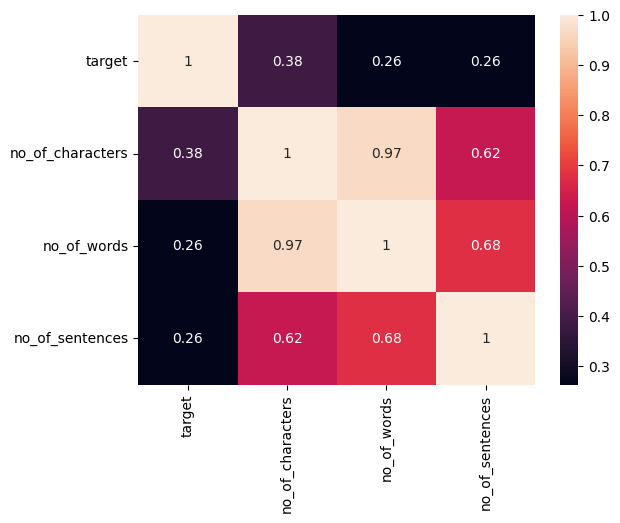

In [14]:
sns.heatmap(data[['target','no_of_characters','no_of_words','no_of_sentences']].corr(),annot=True)

3. DATA PREPROCESSING

In [15]:
## TEXT PROCESSING INVOLVES THESE STEPS ONLY


# 1. Lower case (for uniformity)
# 2. Tokenization (breakdown in words)
# 3. Removing special characters (@,!,&,etc)
# 4. Removing Stopwards and Punctuations
# 5. STtemming

In [16]:
## for step 4

nltk.download('stopwords')

import string
string.punctuation

from nltk.corpus import stopwords
stopwords.words('english')


# for step 5 
 
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
def transform(text):
  text=text.lower()
  text=nltk.word_tokenize(text)

  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)

  text=y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(ps.stem(i))

  return " ".join(y)
  


data['transformed_text']=data['text'].apply(transform)


In [24]:
data.head() 

,target,text,no_of_characters,no_of_words,no_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [26]:
!pip install wordcloud

In [ ]:


from wordcloud import WordCloud

wc=WordCloud(width=500,height=500,min_font_size=10,background_color='pink')

wc.generate(data[data[targ]==1]['transformed_text'])


NameError: name 'target' is not defined